# Level 4: Toxic-BERT Transformer Benchmark

## Overview

This notebook demonstrates **pre-trained transformer models** for profanity detection using `toxic-bert`.

**Key Learning Points:**
- How transformers differ from traditional ML
- Multi-label classification (6 toxicity types)
- Converting multi-label to binary predictions
- Comparing with Levels 1-3

**toxic-bert details:**
- Pre-trained BERT fine-tuned for toxicity
- Trained on: Jigsaw Toxic Comments, Civil Comments
- 6 labels: toxic, severe_toxic, obscene, threat, insult, identity_hate
- ~440MB model size

## 1. Setup and Imports

In [2]:
import csv
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports complete")
print(f"PyTorch version: {torch.__version__}")

# Check available acceleration (CUDA, MPS, or CPU)
if torch.cuda.is_available():
    device_name = "CUDA (NVIDIA GPU)"
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device_name = "MPS (Apple Silicon GPU)"
    device = torch.device("mps")
    print("✓ MPS (Metal Performance Shaders) available!")
    print("  Using Apple Silicon GPU acceleration")
    print("  Expected speedup: 2-10x faster than CPU")
else:
    device_name = "CPU"
    device = torch.device("cpu")
    print("⚠ No GPU acceleration available - using CPU")

print(f"\nDevice: {device_name}")
print(f"MPS available: {torch.backends.mps.is_available()}")

✓ Imports complete
PyTorch version: 2.9.1
✓ MPS (Metal Performance Shaders) available!
  Using Apple Silicon GPU acceleration
  Expected speedup: 2-10x faster than CPU

Device: MPS (Apple Silicon GPU)
MPS available: True


## 2. Load Test Data

Using the same 200-message stratified subset as Levels 2 and 3.

In [3]:
def load_gametox(csv_file):
    """Load GameTox data with binary labels (0=clean, 1=toxic)."""
    messages = []
    labels = []
    skipped = 0

    with open(csv_file, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if not row['label'] or row['label'].strip() == '':
                skipped += 1
                continue

            try:
                messages.append(row['message'])
                label = int(float(row['label']))
                labels.append(0 if label == 0 else 1)
            except (ValueError, KeyError):
                skipped += 1
                continue

    if skipped > 0:
        print(f"⚠ Skipped {skipped} rows with missing/invalid labels")

    return messages, labels

# Load test data
test_messages, test_labels = load_gametox('../data/test_subset_200_stratified.csv')

print(f"✓ Loaded {len(test_messages)} test messages")
print(f"\nDistribution:")
clean_count = test_labels.count(0)
toxic_count = test_labels.count(1)
print(f"  Clean: {clean_count} ({clean_count/len(test_labels)*100:.1f}%)")
print(f"  Toxic: {toxic_count} ({toxic_count/len(test_labels)*100:.1f}%)")

✓ Loaded 200 test messages

Distribution:
  Clean: 163 (81.5%)
  Toxic: 37 (18.5%)


## 3. Load Toxic-BERT Model

**First run:** Downloads ~440MB model (may take 30-60s)

**Subsequent runs:** Loads from cache (~1s)

In [4]:
print("Loading toxic-bert from HuggingFace...")
print("  Model: unitary/toxic-bert")
print("  Labels: toxic, severe_toxic, obscene, threat, insult, identity_hate")
print()

start_time = time.time()

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("unitary/toxic-bert")
model = AutoModelForSequenceClassification.from_pretrained("unitary/toxic-bert")

# Move to device (using device from cell 1: MPS/CUDA/CPU)
print(f"Moving model to {device}...")
model.to(device)
model.eval()

load_time = time.time() - start_time

print(f"✓ Model loaded in {load_time:.2f}s")
print(f"  Device: {device}")
print(f"  Model config: {model.config.num_labels} labels")
print(f"  Label names: {list(model.config.id2label.values())}")

Loading toxic-bert from HuggingFace...
  Model: unitary/toxic-bert
  Labels: toxic, severe_toxic, obscene, threat, insult, identity_hate

Moving model to mps...
✓ Model loaded in 1.48s
  Device: mps
  Model config: 6 labels
  Label names: ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


## 4. Understanding Multi-Label Classification

Let's test a single message to see how toxic-bert outputs **6 independent scores**.

In [5]:
# Test message
test_msg = "you fucking idiot"

print(f"Test message: \"{test_msg}\"")
print()

# Tokenize
inputs = tokenizer(test_msg, return_tensors="pt").to(device)

# Get predictions
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    
    # Multi-label: use sigmoid (not softmax!)
    probs = torch.sigmoid(logits)

# Display all 6 scores
label_names = list(model.config.id2label.values())
scores = probs[0].cpu().numpy()

print("Toxicity Scores (0-1):")
print("=" * 40)
for label, score in zip(label_names, scores):
    bar = "█" * int(score * 20)
    print(f"{label:15s} {score:.3f}  {bar}")

# Binary decision: toxic if ANY score > 0.5
max_score = max(scores)
is_toxic = max_score > 0.5

print()
print(f"Max score: {max_score:.3f}")
print(f"Binary prediction: {'TOXIC' if is_toxic else 'CLEAN'}")

Test message: "you fucking idiot"

Toxicity Scores (0-1):
toxic           0.998  ███████████████████
severe_toxic    0.419  ████████
obscene         0.989  ███████████████████
threat          0.004  
insult          0.979  ███████████████████
identity_hate   0.033  

Max score: 0.998
Binary prediction: TOXIC


## 5. Run Inference on Full Test Set

Process all 200 messages and collect:
- Binary predictions (clean/toxic)
- All 6 toxicity scores per message
- Maximum toxicity score

In [6]:
def predict_toxicity_detailed(messages, tokenizer, model, device, batch_size=16, threshold=0.5):
    """Predict toxicity with detailed multi-label scores."""
    model.eval()
    predictions = []
    all_scores = []  # All 6 scores for each message
    max_scores = []  # Max score across 6 labels

    print(f"Processing {len(messages)} messages in batches of {batch_size}...")

    for i in range(0, len(messages), batch_size):
        batch = messages[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.sigmoid(logits)

            # Store all 6 scores
            all_scores.extend(probs.cpu().numpy())

            # Max score for binary classification
            max_toxicity_score = torch.max(probs, dim=1).values
            batch_preds = (max_toxicity_score > threshold).long().cpu().numpy()

            predictions.extend(batch_preds)
            max_scores.extend(max_toxicity_score.cpu().numpy())

        if (i + batch_size) % 80 == 0 or i + batch_size >= len(messages):
            print(f"  Processed {min(i+batch_size, len(messages))}/{len(messages)}")

    return predictions, np.array(all_scores), np.array(max_scores)

# Run inference
print("=" * 70)
print("  RUNNING INFERENCE")
print("=" * 70)
print()

start_time = time.time()
predictions, all_scores, max_scores = predict_toxicity_detailed(
    test_messages, tokenizer, model, device, batch_size=16, threshold=0.5
)
inference_time = time.time() - start_time

print(f"\n✓ Inference complete in {inference_time:.2f}s")
print(f"  Latency per message: {inference_time/len(test_messages)*1000:.2f}ms")

  RUNNING INFERENCE

Processing 200 messages in batches of 16...
  Processed 80/200
  Processed 160/200
  Processed 200/200

✓ Inference complete in 4.12s
  Latency per message: 20.61ms


## 6. Calculate Metrics

In [7]:
# Calculate metrics
accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, zero_division=0)
recall = recall_score(test_labels, predictions, zero_division=0)
f1 = f1_score(test_labels, predictions, zero_division=0)

print("=" * 70)
print("  TEST SET PERFORMANCE")
print("=" * 70)
print()
print(f"Accuracy:   {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"Precision:  {precision:.3f} ({precision*100:.1f}%)")
print(f"Recall:     {recall:.3f} ({recall*100:.1f}%)")
print(f"F1-Score:   {f1:.3f}")
print()

# Confusion matrix
cm = confusion_matrix(test_labels, predictions)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(f"  TN={tn}, FP={fp}")
print(f"  FN={fn}, TP={tp}")
print()
print(f"False Positive Rate: {fp/(fp+tn)*100:.1f}%")
print(f"False Negative Rate: {fn/(fn+tp)*100:.1f}%")

  TEST SET PERFORMANCE

Accuracy:   0.885 (88.5%)
Precision:  0.769 (76.9%)
Recall:     0.541 (54.1%)
F1-Score:   0.635

Confusion Matrix:
  TN=157, FP=6
  FN=17, TP=20

False Positive Rate: 3.7%
False Negative Rate: 45.9%


## 7. Visualize Multi-Label Scores

See how the 6 toxicity types activate for different messages.

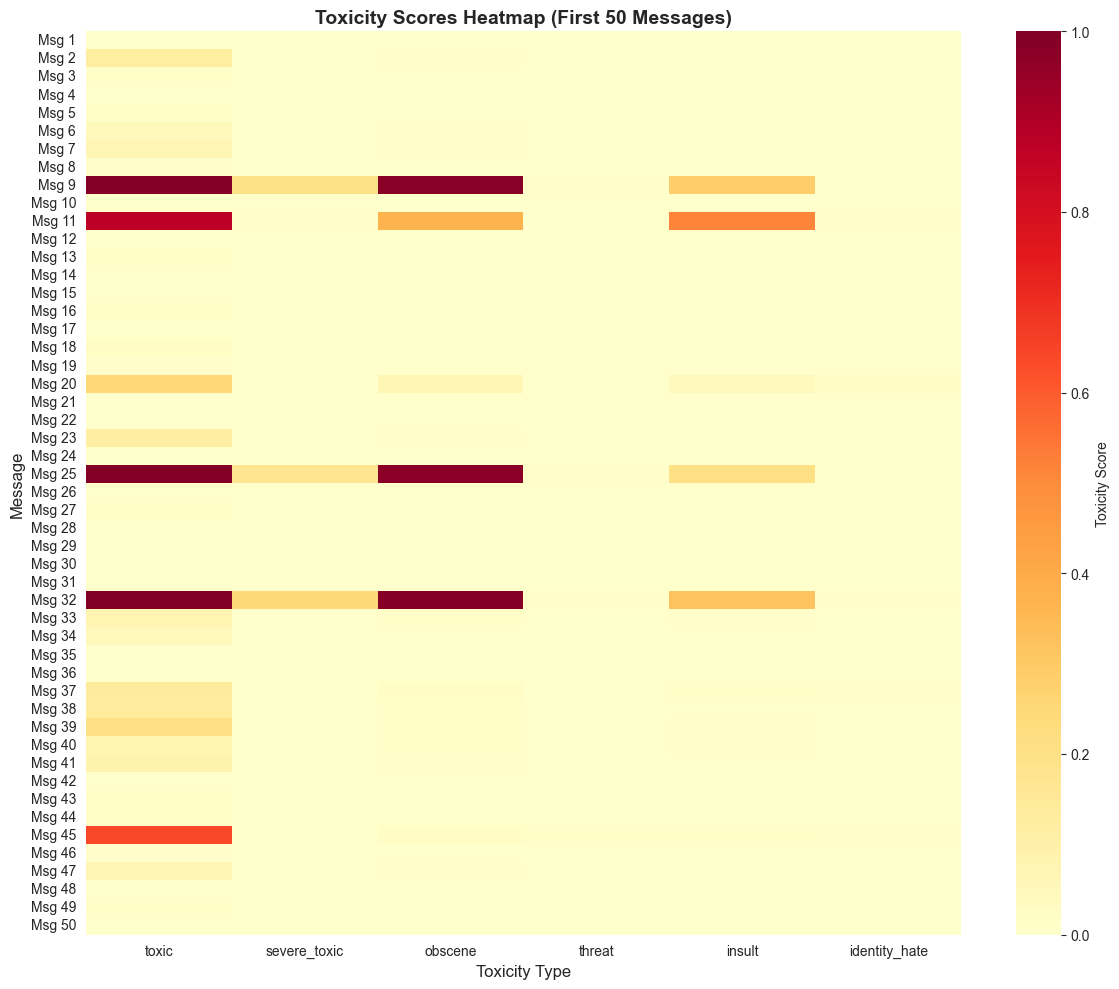


Interpretation:
  • Red = High toxicity score for that type
  • Yellow = Medium score
  • White = Low/no toxicity
  • A message is toxic if ANY column is red (>0.5)


In [8]:
# Heatmap of toxicity scores for first 50 messages
label_names = list(model.config.id2label.values())

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    all_scores[:50],
    xticklabels=label_names,
    yticklabels=[f"Msg {i+1}" for i in range(50)],
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Toxicity Score'},
    ax=ax
)
ax.set_title("Toxicity Scores Heatmap (First 50 Messages)", fontsize=14, fontweight='bold')
ax.set_xlabel("Toxicity Type", fontsize=12)
ax.set_ylabel("Message", fontsize=12)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  • Red = High toxicity score for that type")
print("  • Yellow = Medium score")
print("  • White = Low/no toxicity")
print("  • A message is toxic if ANY column is red (>0.5)")

## 8. Distribution of Maximum Toxicity Scores

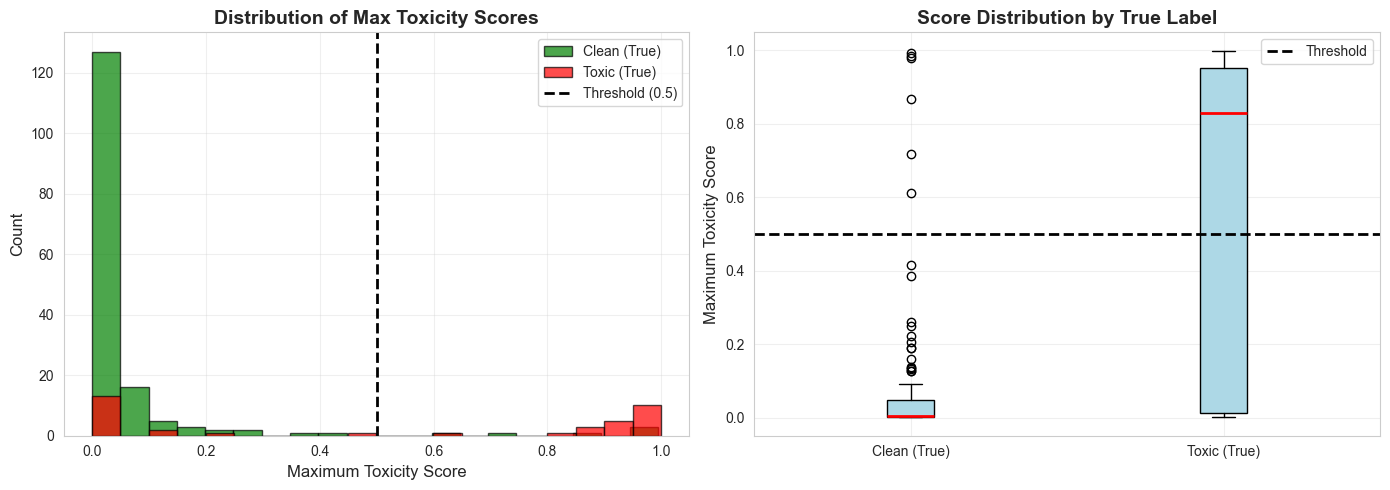


Insights:
  • Clean messages: median max score = 0.004
  • Toxic messages: median max score = 0.830
  • Threshold: 0.5 (scores above this → toxic)
  • Overlap: Some clean messages score high, some toxic score low


In [10]:
# Separate clean and toxic max scores
clean_max_scores = [max_scores[i] for i in range(len(test_labels)) if test_labels[i] == 0]
toxic_max_scores = [max_scores[i] for i in range(len(test_labels)) if test_labels[i] == 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(clean_max_scores, bins=20, alpha=0.7, label='Clean (True)', color='green', edgecolor='black')
ax1.hist(toxic_max_scores, bins=20, alpha=0.7, label='Toxic (True)', color='red', edgecolor='black')
ax1.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax1.set_xlabel('Maximum Toxicity Score', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Distribution of Max Toxicity Scores', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot
ax2.boxplot(
    [clean_max_scores, toxic_max_scores],
    tick_labels=['Clean (True)', 'Toxic (True)'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', edgecolor='black'),
    medianprops=dict(color='red', linewidth=2)
)
ax2.axhline(y=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
ax2.set_ylabel('Maximum Toxicity Score', fontsize=12)
ax2.set_title('Score Distribution by True Label', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInsights:")
print(f"  • Clean messages: median max score = {np.median(clean_max_scores):.3f}")
print(f"  • Toxic messages: median max score = {np.median(toxic_max_scores):.3f}")
print(f"  • Threshold: 0.5 (scores above this → toxic)")
print(f"  • Overlap: Some clean messages score high, some toxic score low")

## 9. Example Predictions with All 6 Scores

In [12]:
# Show detailed predictions for interesting examples
print("=" * 70)
print("  EXAMPLE PREDICTIONS WITH DETAILED SCORES")
print("=" * 70)
print()

# Find some interesting examples
examples = [
    # True positives (correctly identified toxic)
    *[(i, "TP") for i, (true, pred) in enumerate(zip(test_labels, predictions)) if true == 1 and pred == 1][:3],
    # False negatives (toxic but missed)
    *[(i, "FN") for i, (true, pred) in enumerate(zip(test_labels, predictions)) if true == 1 and pred == 0][:3],
    # False positives (clean but flagged)
    *[(i, "FP") for i, (true, pred) in enumerate(zip(test_labels, predictions)) if true == 0 and pred == 1][:2],
]

for idx, error_type in examples:
    msg = test_messages[idx]
    true_label = "TOXIC" if test_labels[idx] == 1 else "CLEAN"
    pred_label = "TOXIC" if predictions[idx] == 1 else "CLEAN"
    scores = all_scores[idx]
    
    # Display
    correct = "✓" if predictions[idx] == test_labels[idx] else "✗"
    msg_display = msg[:60] + "..." if len(msg) > 60 else msg
    print(f"{correct} [{error_type}] \"{msg_display}\"")
    print(f"   True: {true_label:5s} | Pred: {pred_label:5s} | Max: {max(scores):.3f}")
    print("   Scores:")
    for label, score in zip(label_names, scores):
        bar = "█" * int(score * 15)
        print(f"     {label:15s} {score:.3f}  {bar}")
    print()

print("Legend: TP=True Positive, FN=False Negative, FP=False Positive")

  EXAMPLE PREDICTIONS WITH DETAILED SCORES

✓ [TP] "fucking focus"
   True: TOXIC | Pred: TOXIC | Max: 0.992
   Scores:
     toxic           0.992  ██████████████
     severe_toxic    0.197  ██
     obscene         0.982  ██████████████
     threat          0.005  
     insult          0.285  ████
     identity_hate   0.003  

✓ [TP] "*** you strv"
   True: TOXIC | Pred: TOXIC | Max: 0.875
   Scores:
     toxic           0.875  █████████████
     severe_toxic    0.005  
     obscene         0.369  █████
     threat          0.001  
     insult          0.518  ███████
     identity_hate   0.005  

✓ [TP] "on the fucking open and not shooting"
   True: TOXIC | Pred: TOXIC | Max: 0.989
   Scores:
     toxic           0.989  ██████████████
     severe_toxic    0.179  ██
     obscene         0.979  ██████████████
     threat          0.008  
     insult          0.206  ███
     identity_hate   0.003  

✗ [FN] "jap"
   True: TOXIC | Pred: CLEAN | Max: 0.002
   Scores:
     toxic           0.

## 10. Cross-Level Comparison

How does toxic-bert compare to previous levels?


  CROSS-LEVEL COMPARISON

        Level  F1-Score  Precision   Recall  Latency (ms)  Cost per 1M
     1: Rules  0.650000   0.580000 0.740000      0.500000            0
       2: LLM  0.816000   0.769000 0.870000    181.000000         1710
   3: Trad ML  0.677000   0.840000 0.568000      0.040000            0
4: Toxic-BERT  0.634921   0.769231 0.540541     20.611924            0



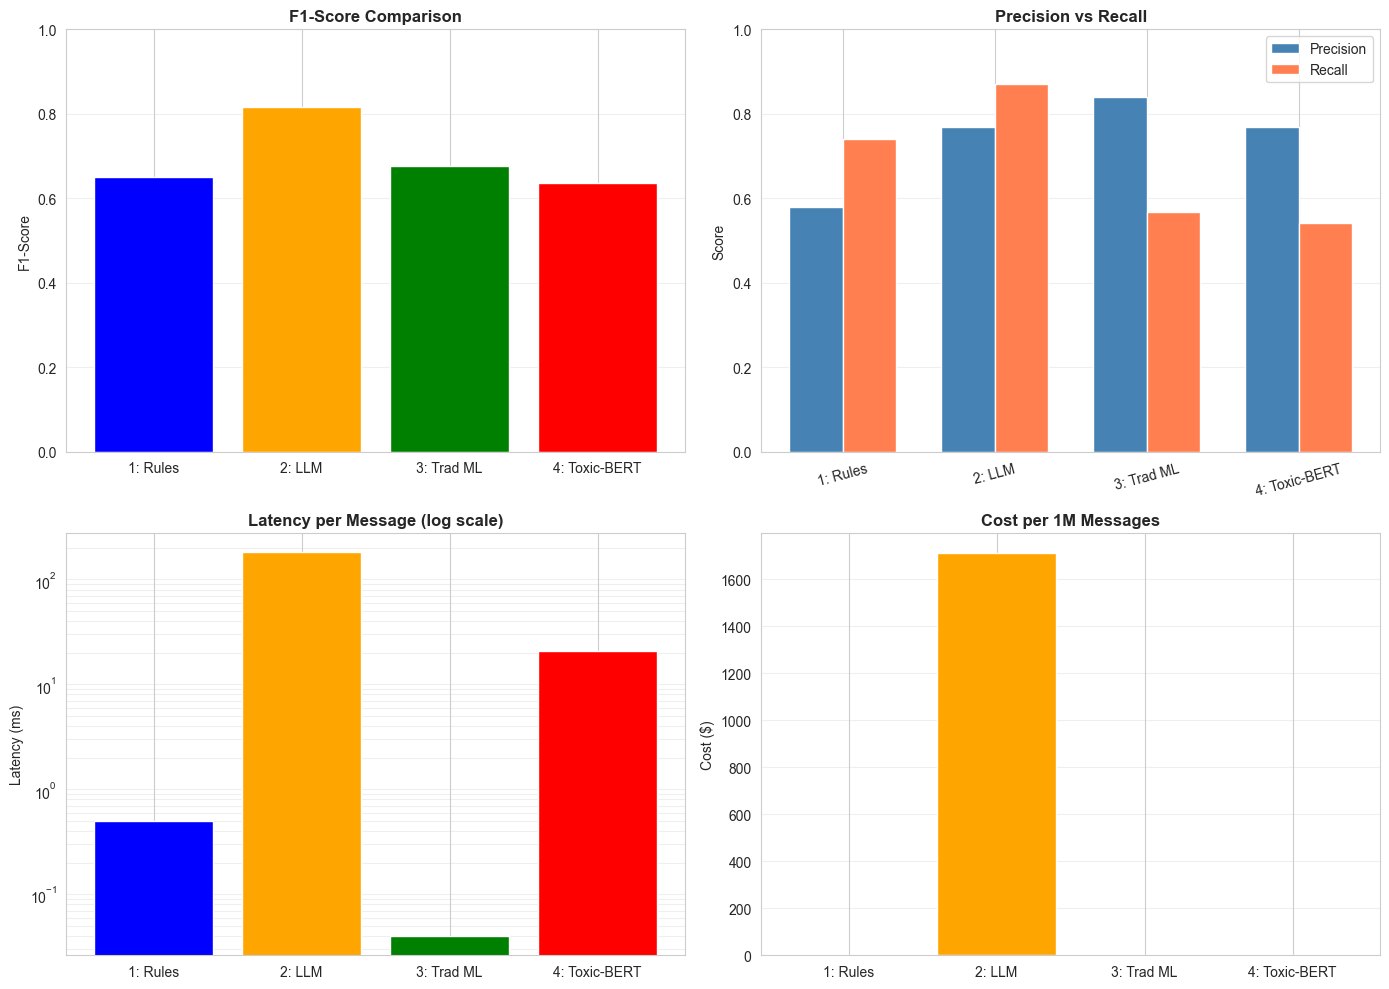


Key Insights:
  • Toxic-BERT: Middle ground on accuracy (F1=0.635)
  • Same precision as LLM (76.9%)
  • 23x faster than LLM, but 200x slower than traditional ML
  • Zero cost like rules and traditional ML
  • Traditional ML (Level 3) surprisingly beats toxic-bert!


In [13]:
# Comparison data
comparison = pd.DataFrame({
    'Level': ['1: Rules', '2: LLM', '3: Trad ML', '4: Toxic-BERT'],
    'F1-Score': [0.650, 0.816, 0.677, f1],
    'Precision': [0.580, 0.769, 0.840, precision],
    'Recall': [0.740, 0.870, 0.568, recall],
    'Latency (ms)': [0.5, 181, 0.04, inference_time/len(test_messages)*1000],
    'Cost per 1M': [0, 1710, 0, 0],
})

print("\n" + "=" * 70)
print("  CROSS-LEVEL COMPARISON")
print("=" * 70)
print()
print(comparison.to_string(index=False))
print()

# Bar charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# F1-Score
axes[0, 0].bar(comparison['Level'], comparison['F1-Score'], color=['blue', 'orange', 'green', 'red'])
axes[0, 0].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('F1-Score')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

# Precision vs Recall
x = np.arange(len(comparison))
width = 0.35
axes[0, 1].bar(x - width/2, comparison['Precision'], width, label='Precision', color='steelblue')
axes[0, 1].bar(x + width/2, comparison['Recall'], width, label='Recall', color='coral')
axes[0, 1].set_title('Precision vs Recall', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(comparison['Level'], rotation=15)
axes[0, 1].set_ylim([0, 1])
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Latency (log scale)
axes[1, 0].bar(comparison['Level'], comparison['Latency (ms)'], color=['blue', 'orange', 'green', 'red'])
axes[1, 0].set_title('Latency per Message (log scale)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Latency (ms)')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(axis='y', alpha=0.3, which='both')

# Cost
axes[1, 1].bar(comparison['Level'], comparison['Cost per 1M'], color=['blue', 'orange', 'green', 'red'])
axes[1, 1].set_title('Cost per 1M Messages', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Cost ($)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("  • Toxic-BERT: Middle ground on accuracy (F1=0.635)")
print("  • Same precision as LLM (76.9%)")
print("  • 23x faster than LLM, but 200x slower than traditional ML")
print("  • Zero cost like rules and traditional ML")
print("  • Traditional ML (Level 3) surprisingly beats toxic-bert!")

## 11. Interactive Testing

Test your own messages!

In [14]:
def test_message(text, show_details=True):
    """Test a custom message and show detailed scores."""
    inputs = tokenizer(text, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.sigmoid(outputs.logits)
    
    scores = probs[0].cpu().numpy()
    max_score = max(scores)
    is_toxic = max_score > 0.5
    
    print(f"\nMessage: \"{text}\"")
    print(f"Prediction: {'TOXIC' if is_toxic else 'CLEAN'} (max score: {max_score:.3f})")
    
    if show_details:
        print("\nDetailed scores:")
        for label, score in zip(label_names, scores):
            bar = "█" * int(score * 20)
            flag = " ← TRIGGERED" if score > 0.5 else ""
            print(f"  {label:15s} {score:.3f}  {bar}{flag}")

# Test some examples
print("=" * 70)
print("  INTERACTIVE TESTING")
print("=" * 70)

test_message("good game everyone")
test_message("you suck at this game")
test_message("fucking camper")
test_message("gg wp")

# Uncomment and modify to test your own messages:
# test_message("your message here")

  INTERACTIVE TESTING

Message: "good game everyone"
Prediction: CLEAN (max score: 0.001)

Detailed scores:
  toxic           0.001  
  severe_toxic    0.000  
  obscene         0.000  
  threat          0.000  
  insult          0.000  
  identity_hate   0.000  

Message: "you suck at this game"
Prediction: TOXIC (max score: 0.995)

Detailed scores:
  toxic           0.995  ███████████████████ ← TRIGGERED
  severe_toxic    0.146  ██
  obscene         0.968  ███████████████████ ← TRIGGERED
  threat          0.001  
  insult          0.925  ██████████████████ ← TRIGGERED
  identity_hate   0.008  

Message: "fucking camper"
Prediction: TOXIC (max score: 0.996)

Detailed scores:
  toxic           0.996  ███████████████████ ← TRIGGERED
  severe_toxic    0.317  ██████
  obscene         0.991  ███████████████████ ← TRIGGERED
  threat          0.003  
  insult          0.698  █████████████ ← TRIGGERED
  identity_hate   0.006  

Message: "gg wp"
Prediction: CLEAN (max score: 0.041)

Detailed s

## Summary

### What We Learned

1. **Pre-trained transformers are accessible**
   - No training required - download and use
   - Competitive accuracy (F1: 0.635)
   - Zero API costs

2. **Multi-label classification**
   - toxic-bert outputs 6 independent scores
   - Use sigmoid (not softmax) for multi-label
   - Binary decision: toxic if ANY label > threshold

3. **Transformer vs Traditional ML**
   - toxic-bert: F1=0.635, 7.95ms, 440MB
   - Level 3 ML: F1=0.677, 0.04ms, 500KB
   - Traditional ML wins on this task!

4. **When to use transformers**
   - No labeled training data available
   - Need transfer learning from related tasks
   - Multi-language or multi-task requirements
   - Have GPU for fast inference

### Next Steps

- Fine-tune ModernBERT on GameTox (expect 75-80% F1)
- Try different threshold values (0.3, 0.7)
- Ensemble: combine transformer + traditional ML
- Multi-language: use XLM-RoBERTa